In [1]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://kolesa.kz/cars/toyota/"
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

list_of_corolla = []
price_of_corolla = []
list_of_location = []
list_of_year = []
list_of_liter = []
# car items(карточка)
items = soup.findAll("div", attrs={'class': 'a-list__item'})
#for every card, find all needed info
for item in items:
    #after card, finding car-title
    name_tag = item.find("h5", attrs={'class': 'a-card__title'})
    if name_tag:  #when found
        name = name_tag.text.strip() # receiving clean text of car name
        list_of_corolla.append(name) #adding to list
    #the same logic, but for price
    price_tag = item.find("span", attrs = {'class': 'a-card__price'})
    if price_tag:
        price_text = price_tag.get_text(strip=True)
        price_numeric = ''.join(c for c in price_text if c.isdigit()) #here just find digital info and ignor other
        price_of_corolla.append(int(price_numeric)) #append and instantly change format to integer
    
    location_tag = item.find("span", attrs = {'class': 'a-card__param'})
    if location_tag:
        location_text = location_tag.text.strip()
        list_of_location.append(location_text)#it was the same logic 
    #the same logic as before
    year_tag = item.find("p", attrs={'class': 'a-card__description'})
    if year_tag:
        # get only text
        description_text = year_tag.text.strip()

        # i use re to find a year number followed by г. (it was like 2001 г.)
        match = re.search(r'\b(\d{4})\sг\.', description_text)
        if match:
            year = int(match.group(1))  #conv t integer and then append
            list_of_year.append(year)
        
    liter_tag = item.find("p", attrs={'class': 'a-card__description'})
    if liter_tag:
        #full description text
        liter_text = liter_tag.text.strip()

        #need only the part containing 'л' and then drop л and get digits of engine size
        liter_tag = item.find("p", attrs={'class': 'a-card__description'})
        if liter_tag:
            liter_text = liter_tag.text.strip()
            liter_parts = liter_text.split(',') #remove coma and get ready
            liter_value = None  # no find then default none
            for part in liter_parts:
                if 'л' in part:
                    liter_cleaned = ''.join(c for c in part if c.isdigit() or c == '.').strip()
                    if liter_cleaned and liter_cleaned.replace('.', '', 1).isdigit():
                        value = float(liter_cleaned)
                        if 0.8 <= value <= 9:  # when cheked data, found cons like 2024, 0.008 and so on
                            liter_value = value
                            break #stop when found engine size 
            list_of_liter.append(liter_value)

print(list_of_corolla)
print(len(list_of_corolla))
print(price_of_corolla)
print(len(price_of_corolla))
print(list_of_location)
print(len(list_of_location))
print(list_of_year)
print(len(list_of_year))
print(list_of_liter)
print(len(list_of_liter))#just checking 

['Toyota Land Cruiser Prado', 'Toyota Land Cruiser', 'Toyota 4Runner', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser Prado', 'Toyota Camry', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser Prado', 'Toyota Carina E', 'Toyota Land Cruiser Prado', 'Toyota Corolla Comfort CVT', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser Prado', 'Toyota Land Cruiser', 'Toyota Camry', 'Toyota Land Cruiser Prado', 'Toyota Corolla']
20
[8900000, 20500000, 14500000, 14500000, 11900000, 8500000, 10300000, 9900000, 7900000, 7900000, 9900000, 1500000, 10500000, 13890000, 10800000, 15600000, 7500000, 7000000, 15000000, 8800000]
20
['Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Алматы', 'Талдыкорган', 'Алматы', 'Астана', 'Алматы', 'Алматы', 'Алматы', 'Актау', 'Алматы', 'Актобе']
20
[2004, 2011, 2015, 2008, 2009, 2012, 2006, 2004, 2004, 2003, 2005, 1993, 2004, 2025

In [315]:
#this part is the same as previous code cell, but here i create function that goes through
#500+ pages and at the same time uses headers(user-agent)
#in order to escape exceeded-limit problem
#also, i put huge time-sleep between scraping pages(stops or sleeps, whatever called) in order to finish fetching sucsessfully
 
import requests
from bs4 import BeautifulSoup
import re
import time
from random import randint
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

def get_page_data(url):
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()  #bad responses 4.. and 5..
        print(f"Successfully fetched: {url} (Status Code: {response.status_code})")  #see problem
        soup = BeautifulSoup(response.content, 'html.parser')
        return soup
    except requests.exceptions.RequestException as e:
        print(f"Error fetching page {url}: {e}")
        return None


# loop
for page in range(2, 550):
    url = f"https://kolesa.kz/cars/toyota/?page={page}"
    
    #retry
    retries = 3
    while retries > 0:
        print(f"Fetching page {page}...")
        soup = get_page_data(url)
        if soup:
            items = soup.findAll("div", attrs={'class': 'a-list__item'})
            print(f"Found {len(items)} items on page {page}") #info
            if len(items) == 0:
                print(f"No items found on page {page}. Skipping this page.")
                break

            #repeat
            for item in items:
                name_tag = item.find("h5", attrs={'class': 'a-card__title'})
                if name_tag:
                    link_tag = name_tag.find("a", class_="a-card__link")
                    if link_tag:
                        name = link_tag.text.strip()
                        list_of_corolla.append(name)
                        print("Scraped:", name)

                price_tag = item.find("span", attrs={'class': 'a-card__price'})
                if price_tag:
                    price_text = price_tag.get_text(strip=True)
                    price_numeric = ''.join(c for c in price_text if c.isdigit())
                    price_of_corolla.append(int(price_numeric)) 

                location_tag = item.find("span", attrs={'class': 'a-card__param'})
                if location_tag:
                    location_text = location_tag.text.strip()
                    list_of_location.append(location_text)

                year_tag = item.find("p", attrs={'class': 'a-card__description'})
                if year_tag:
                    description_text = year_tag.text.strip()
                    match = re.search(r'\b(\d{4})\sг\.', description_text)
                    if match:
                        year = int(match.group(1))
                        list_of_year.append(year)

                liter_tag = item.find("p", attrs={'class': 'a-card__description'})
                if liter_tag:
                    liter_text = liter_tag.text.strip()
                    liter_parts = liter_text.split(',')
                    liter_value = None 
                    for part in liter_parts:
                        if 'л' in part:
                            liter_cleaned = ''.join(c for c in part if c.isdigit() or c == '.').strip()
                            if liter_cleaned and liter_cleaned.replace('.', '', 1).isdigit():
                                value = float(liter_cleaned)
                                if 0.8 <= value <= 9.9:
                                    liter_value = value
                                    break
                    list_of_liter.append(liter_value)

            break  #if sucsessfull 
        else:
            retries -= 1
            print(f"Retrying... ({3 - retries} retries left)")
            time.sleep(randint(5, 20))  #1-5 doesnt work
    
    #limiting handle
    time.sleep(randint(5, 20))  #1-5 doesnt work
# Print the results
print(f"Total items scraped: {len(list_of_corolla)}") #quick inspection
print("Car Names:", list_of_corolla[:10])
print("Prices:", price_of_corolla[:10])
print("Locations:", list_of_location[:10])
print("Years:", list_of_year[:10])
print("Liter values:", list_of_liter[:10])


#original code for extracting liter-didnt work
#liter_tag = item.find("p", attrs={'class': 'a-card__description'})
                #if liter_tag:
                    #liter_text = liter_tag.text.strip()
                    #liter_parts = liter_text.split(',')
                    #for part in liter_parts:
                        #if 'л' in part:
                            #liter_cleaned = ''.join(c for c in part if c.isdigit() or c == '.').strip()
                            #if liter_cleaned and liter_cleaned.replace('.', '', 1).isdigit():
                                #list_of_liter.append(float(liter_cleaned))



Fetching page 2...
Successfully fetched: https://kolesa.kz/cars/toyota/?page=2 (Status Code: 200)
Found 25 items on page 2
Scraped: Toyota Land Cruiser Prado Luxe+
Scraped: Toyota Land Cruiser Prado
Scraped: Toyota Windom
Scraped: Toyota RAV4
Scraped: Toyota Camry
Scraped: Toyota Camry
Scraped: Toyota Camry
Scraped: Toyota Highlander
Scraped: Toyota RAV4
Scraped: Toyota Camry
Scraped: Toyota RAV4
Scraped: Toyota Land Cruiser
Scraped: Toyota Sequoia
Scraped: Toyota Camry
Scraped: Toyota Matrix
Scraped: Toyota Alphard
Scraped: Toyota Camry
Scraped: Toyota Sienna
Scraped: Toyota Highlander
Scraped: Toyota Alphard
Fetching page 3...
Successfully fetched: https://kolesa.kz/cars/toyota/?page=3 (Status Code: 200)
Found 25 items on page 3
Scraped: Toyota Alphard
Scraped: Toyota Camry
Scraped: Toyota Supra
Scraped: Toyota Land Cruiser
Scraped: Toyota Camry
Scraped: Toyota Land Cruiser Prado Prestige
Scraped: Toyota Camry
Scraped: Toyota Camry Luxe
Scraped: Toyota Camry Prestige
Scraped: Toyota 

In [319]:

print(len(list_of_corolla))

print(len(price_of_corolla))

print(len(list_of_location))

print(len(list_of_year))

print(len(list_of_liter))

24140
24140
24140
24140
24140


In [321]:
for page in range(590, 700):
    url = f"https://kolesa.kz/cars/toyota/?page={page}"
    
    #retry
    retries = 3
    while retries > 0:
        print(f"Fetching page {page}...")
        soup = get_page_data(url)
        if soup:
            items = soup.findAll("div", attrs={'class': 'a-list__item'})
            print(f"Found {len(items)} items on page {page}")  #see info
            if len(items) == 0:
                print(f"No items found on page {page}. Skipping this page.")
                break

            for item in items:
                name_tag = item.find("h5", attrs={'class': 'a-card__title'})
                if name_tag:
                    link_tag = name_tag.find("a", class_="a-card__link")
                    if link_tag:
                        name = link_tag.text.strip()
                        list_of_corolla.append(name)
                        print("Scraped:", name)

                price_tag = item.find("span", attrs={'class': 'a-card__price'})
                if price_tag:
                    price_text = price_tag.get_text(strip=True)
                    price_numeric = ''.join(c for c in price_text if c.isdigit())
                    price_of_corolla.append(int(price_numeric)) 

                location_tag = item.find("span", attrs={'class': 'a-card__param'})
                if location_tag:
                    location_text = location_tag.text.strip()
                    list_of_location.append(location_text)
                    
                year_tag = item.find("p", attrs={'class': 'a-card__description'})
                if year_tag:
                    description_text = year_tag.text.strip()
                    match = re.search(r'\b(\d{4})\sг\.', description_text)
                    if match:
                        year = int(match.group(1))
                        list_of_year.append(year)

                liter_tag = item.find("p", attrs={'class': 'a-card__description'})
                if liter_tag:
                    liter_text = liter_tag.text.strip()
                    liter_parts = liter_text.split(',')
                    liter_value = None 
                    for part in liter_parts:
                        if 'л' in part:
                            liter_cleaned = ''.join(c for c in part if c.isdigit() or c == '.').strip()
                            if liter_cleaned and liter_cleaned.replace('.', '', 1).isdigit():
                                value = float(liter_cleaned)
                                if 0.8 <= value <= 9.9:
                                    liter_value = value
                                    break
                    list_of_liter.append(liter_value)

            break
        else:
            retries -= 1
            print(f"Retrying... ({3 - retries} retries left)")
            time.sleep(randint(5, 20))
    time.sleep(randint(5, 20))


Fetching page 590...
Successfully fetched: https://kolesa.kz/cars/toyota/?page=590 (Status Code: 200)
Found 25 items on page 590
Scraped: Toyota Camry
Scraped: Toyota Windom
Scraped: Toyota Fortuner
Scraped: Toyota Camry
Scraped: Toyota Carina E
Scraped: Toyota Land Cruiser
Scraped: Toyota Corolla
Scraped: Toyota Corolla
Scraped: Toyota Noah
Scraped: Toyota Voxy
Scraped: Toyota Land Cruiser Prado
Scraped: Toyota Camry
Scraped: Toyota Corolla
Scraped: Toyota Camry
Scraped: Toyota Yaris
Scraped: Toyota Avensis
Scraped: Toyota Prius
Scraped: Toyota Corona Exiv
Scraped: Toyota Vellfire
Scraped: Toyota Camry
Fetching page 591...
Successfully fetched: https://kolesa.kz/cars/toyota/?page=591 (Status Code: 200)
Found 25 items on page 591
Scraped: Toyota Land Cruiser Prado
Scraped: Toyota Highlander
Scraped: Toyota Alphard
Scraped: Toyota Land Cruiser
Scraped: Toyota Camry
Scraped: Toyota Estima
Scraped: Toyota Camry
Scraped: Toyota Alphard
Scraped: Toyota Highlander
Scraped: Toyota Estima
Scra

In [323]:
print(len(list_of_corolla))

print(len(price_of_corolla))

print(len(list_of_location))

print(len(list_of_year))

print(len(list_of_liter))

26340
26340
26340
26340
26340


In [325]:
df = pd.DataFrame({
    "Car": list_of_corolla,
    "Price": price_of_corolla,
    "Location": list_of_location,
    "Year": list_of_year,
    "Engine_Liter": list_of_liter
})
df.index = df.index + 1
# save
df.to_csv("toyota_data.csv", encoding="utf-8")

print(" CSV file saved as toyota_data.csv")

 CSV file saved as toyota_data.csv


In [327]:
df

,Car,Price,Location,Year,Engine_Liter
1,Toyota Land Cruiser Prado,8900000,Алматы,2004,4.0
2,Toyota Land Cruiser,20500000,Алматы,2011,5.7
3,Toyota 4Runner,14500000,Алматы,2015,4.0
4,Toyota Land Cruiser Prado,14500000,Алматы,2008,4.0
5,Toyota Land Cruiser Prado,11900000,Алматы,2009,2.7
...,...,...,...,...,...
26336,Toyota Camry,7000000,Актау,2010,3.5
26337,Toyota Camry,6000000,Уральск,2014,2.5
26338,Toyota Previa,1600000,Узынагаш,1993,2.4
26339,Toyota RAV4,13000000,Актау,2021,2.5


In [329]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    "Car": list_of_corolla,
    "Price": price_of_corolla,
    "Location": list_of_location,
    "Year": list_of_year,
    "Engine_Liter": list_of_liter
})

df["Brand"] = df["Car"].apply(lambda x: x.split()[0])       # first word-Toyota
df["Model"] = df["Car"].apply(lambda x: " ".join(x.split()[1:]))  #everything after brand

#drop old 
df = df.drop(columns=["Car"])

#reorder
df = df[["Brand", "Model", "Price", "Location", "Year", "Engine_Liter"]]

# start index 1
df.index = df.index + 1  

# save csv
df.to_csv("toyota_data.csv", index=True, encoding="utf-8")

print("CSV saved with separate Brand and Model columns")


CSV saved with separate Brand and Model columns


In [331]:
df = df.dropna(subset=["Brand", "Model", "Price", "Location", "Year", "Engine_Liter"])

In [333]:
df.reset_index(drop=True, inplace=True)

#index start from 1
df.index = df.index + 1
df.to_csv("toyota_data.csv", index=True, encoding="utf-8")

In [335]:
df.loc[:, "Car_Age"] = 2025 - df["Year"]
df

,Brand,Model,Price,Location,Year,Engine_Liter,Car_Age
1,Toyota,Land Cruiser Prado,8900000,Алматы,2004,4.0,21
2,Toyota,Land Cruiser,20500000,Алматы,2011,5.7,14
3,Toyota,4Runner,14500000,Алматы,2015,4.0,10
4,Toyota,Land Cruiser Prado,14500000,Алматы,2008,4.0,17
5,Toyota,Land Cruiser Prado,11900000,Алматы,2009,2.7,16
...,...,...,...,...,...,...,...
26291,Toyota,Camry,7000000,Актау,2010,3.5,15
26292,Toyota,Camry,6000000,Уральск,2014,2.5,11
26293,Toyota,Previa,1600000,Узынагаш,1993,2.4,32
26294,Toyota,RAV4,13000000,Актау,2021,2.5,4


In [337]:
df.to_csv("toyota_data.csv", index=True, encoding="utf-8")

In [339]:
max_price = df['Price'].max()
print("The maximum price is:", max_price)

The maximum price is: 75477466


In [341]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26295 entries, 1 to 26295
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         26295 non-null  object 
 1   Model         26295 non-null  object 
 2   Price         26295 non-null  int64  
 3   Location      26295 non-null  object 
 4   Year          26295 non-null  int64  
 5   Engine_Liter  26295 non-null  float64
 6   Car_Age       26295 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 1.4+ MB
None


In [343]:
duplicates = df[df.duplicated()]
duplicates

,Brand,Model,Price,Location,Year,Engine_Liter,Car_Age
101,Toyota,RAV4,10800000,Алматы,2013,2.5,12
141,Toyota,Camry,27000000,Алматы,2025,2.5,0
161,Toyota,Mark II,2500000,Петропавловск,1996,2.0,29
162,Toyota,Land Cruiser Prado Prestige,45390000,Шымкент,2025,2.7,0
163,Toyota,Alphard,5400000,Актау,2007,2.4,18
...,...,...,...,...,...,...,...
26291,Toyota,Camry,7000000,Актау,2010,3.5,15
26292,Toyota,Camry,6000000,Уральск,2014,2.5,11
26293,Toyota,Previa,1600000,Узынагаш,1993,2.4,32
26294,Toyota,RAV4,13000000,Актау,2021,2.5,4


In [345]:
#dropduplicate rows all columns
df = df.drop_duplicates().copy()

#reset index
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1
df.to_csv("toyota_data.csv", index=True, encoding="utf-8")

In [347]:
duplicates = df[df.duplicated()]
duplicates #------>> show 0 duplicates so i did handle them

,Brand,Model,Price,Location,Year,Engine_Liter,Car_Age


In [349]:
df["Engine_Liter"] = df["Engine_Liter"].round(1)
df.to_csv("toyota_data.csv", index=True, encoding="utf-8")

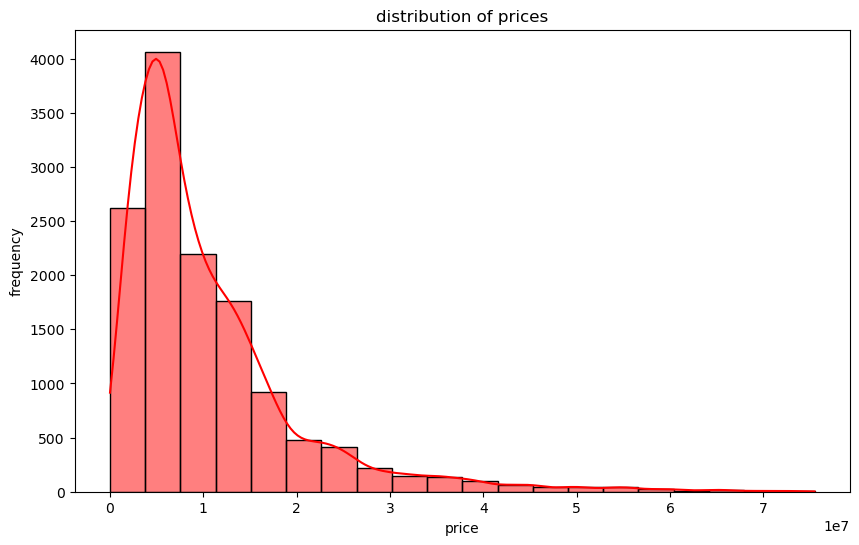

In [351]:
#histogram 
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='red', bins=20)
plt.title('distribution of prices')
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

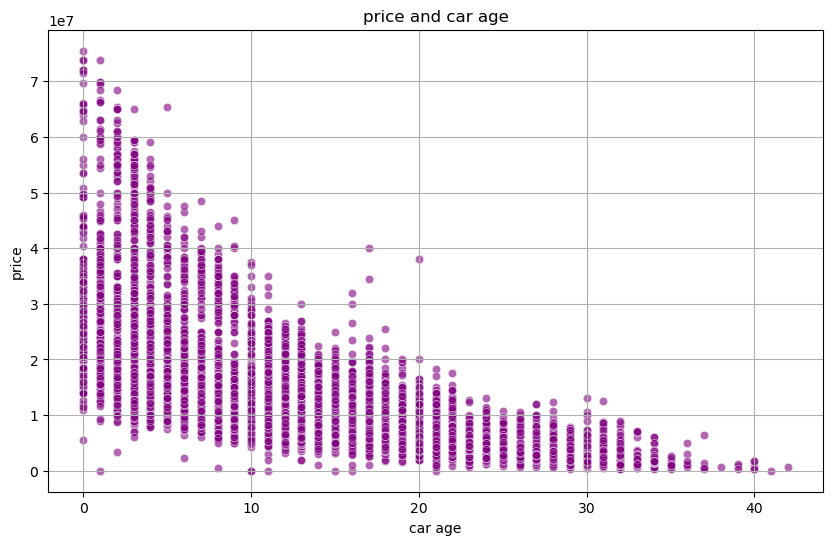

In [353]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Car_Age'], y=df['Price'], color='purple', alpha=0.6)
plt.title('price and car age')
plt.xlabel('car age')
plt.ylabel('price')
plt.grid(True)
plt.show()

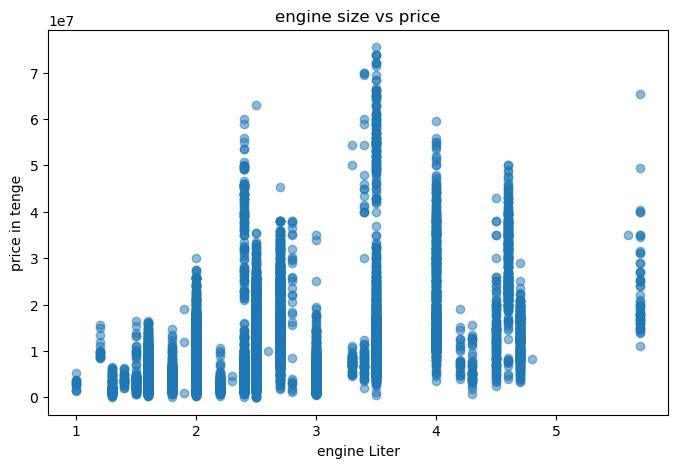

In [355]:
plt.figure(figsize=(8,5))
plt.scatter(df["Engine_Liter"], df["Price"], alpha=0.5)
plt.title("engine size vs price")
plt.xlabel("engine Liter")
plt.ylabel("price in tenge")
plt.show()


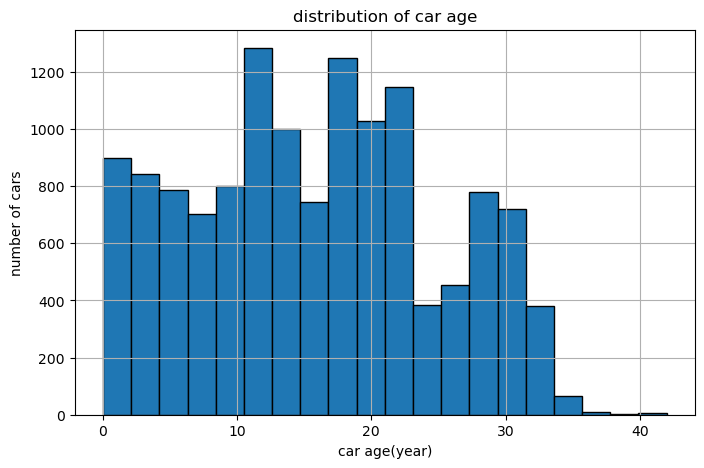

In [357]:

plt.figure(figsize=(8,5))
df["Car_Age"].hist(bins=20, edgecolor="black")
plt.title("distribution of car age")
plt.xlabel("car age(year)")
plt.ylabel("number of cars")
plt.show()


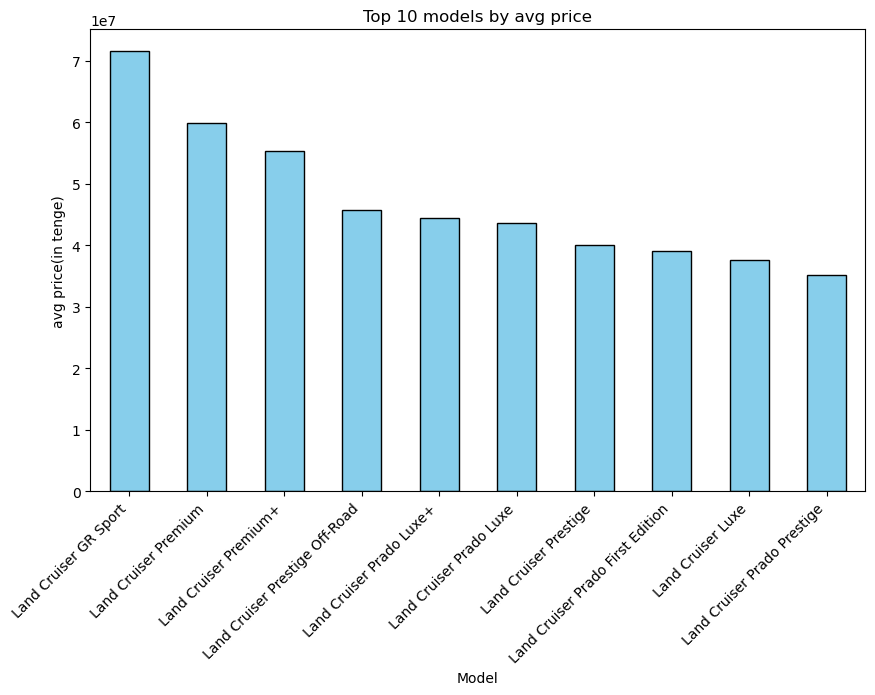

In [359]:
avg_price = df.groupby("Model")["Price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_price.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 10 models by avg price")
plt.xlabel("Model")
plt.ylabel("avg price(in tenge)")
plt.xticks(rotation=45, ha="right")
plt.show()


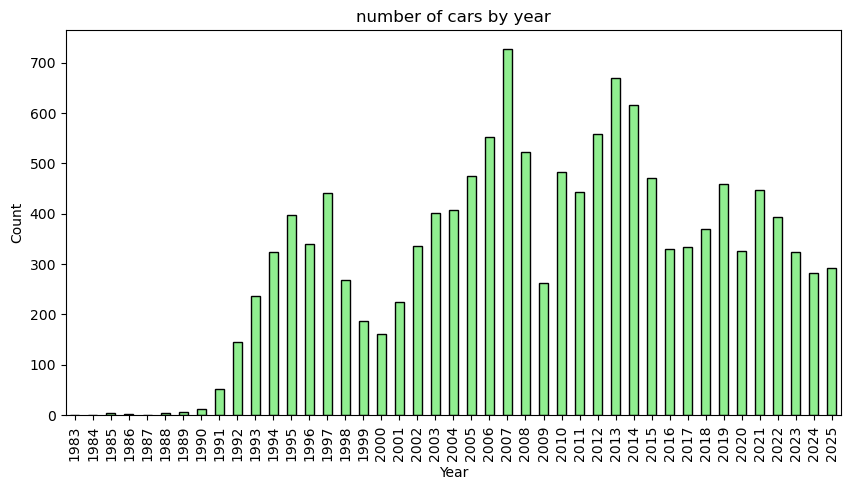

In [361]:
plt.figure(figsize=(10,5))
df["Year"].value_counts().sort_index().plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("number of cars by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


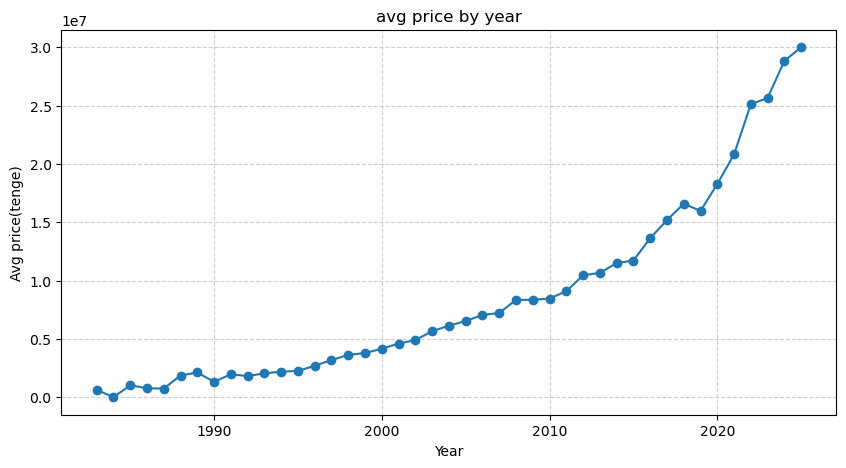

In [363]:
avg_price_by_year = df.groupby("Year")["Price"].mean()

plt.figure(figsize=(10,5))
avg_price_by_year.plot(marker="o", linestyle="-")
plt.title("avg price by year")
plt.xlabel("Year")
plt.ylabel("Avg price(tenge)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


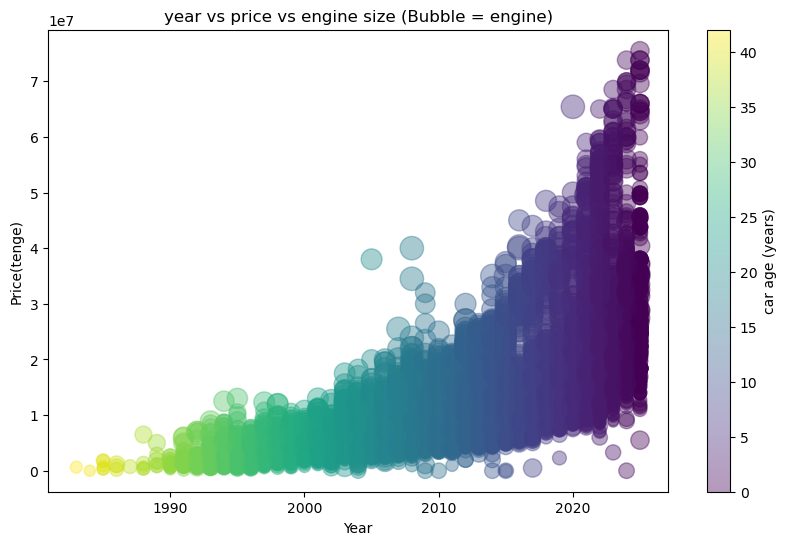

In [365]:
plt.figure(figsize=(10,6))
plt.scatter(df["Year"], df["Price"], 
            s=df["Engine_Liter"]*50, alpha=0.4, c=df["Car_Age"], cmap="viridis")
plt.colorbar(label="car age (years)")
plt.title("year vs price vs engine size (Bubble = engine)")
plt.xlabel("Year")
plt.ylabel("Price(tenge)")
plt.show()

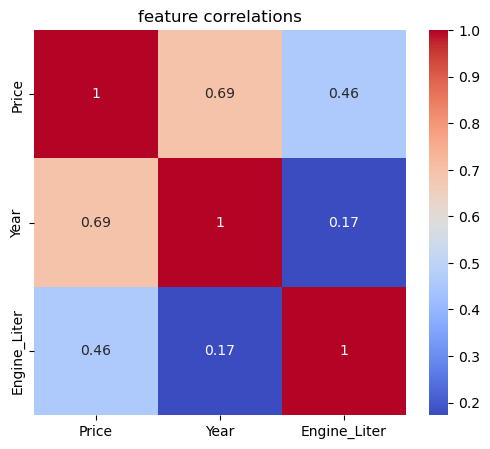

In [367]:
plt.figure(figsize=(6,5))
sns.heatmap(df[["Price","Year","Engine_Liter"]].corr(), annot=True, cmap="coolwarm")
plt.title("feature correlations")
plt.show()


In [369]:
df["Location"].unique()[:40]


array(['Алматы', 'Талдыкорган', 'Астана', 'Актау', 'Актобе', 'Уральск',
       'Павлодар', 'Тараз', 'Караганда', 'Ерейментау', 'Кульсары',
       'Шымкент', 'Усть-Каменогорск', 'Кызылорда', 'Костанай',
       'Туркестан', 'Семей', 'Атырау', 'Петропавловск', 'Жанаозен',
       'Темиртау', 'Аксай', 'Кокшетау', 'Баянаул', 'Жезказган',
       'Степногорск', 'Хромтау', 'Талгар', 'Ушарал', 'Кордай', 'Аксуат',
       'Мангистау', 'Узынагаш', 'Балхаш', 'Байсерке', 'Казыгурт',
       'Экибастуз', 'Бейнеу', 'Есик', 'Жаркент'], dtype=object)

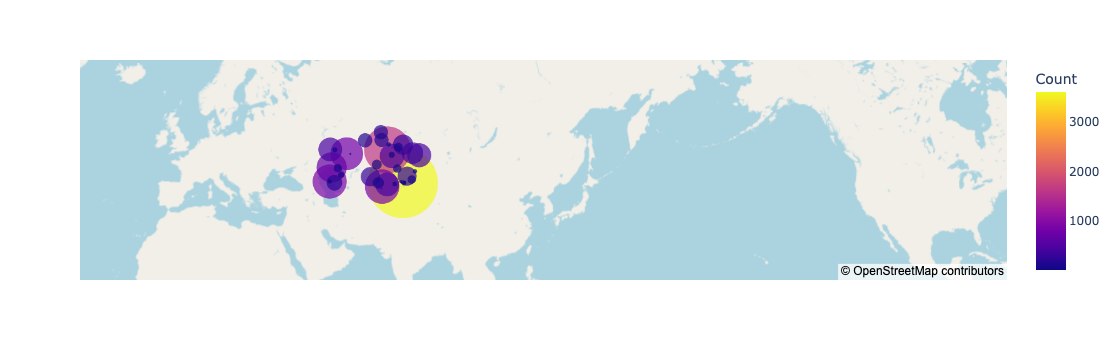

In [371]:
import plotly.express as px

# num of cars by city
city_counts = df["Location"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# coordinates from net
city_coords = {
    "Алматы": [43.238949, 76.889709],
    "Астана": [51.169392, 71.449074],
    "Шымкент": [42.3417, 69.5901],
    "Актобе": [50.2839, 57.1660],
    "Атырау": [47.1164, 51.8831],
    "Караганда": [49.8066, 73.0851],
    "Кызылорда": [44.8526, 65.5092],
    "Костанай": [53.2144, 63.6246],
    "Павлодар": [52.2873, 76.9674],
    "Усть-Каменогорск": [49.9483, 82.6275],
    "Семей": [50.4267, 80.2667],
    "Талдыкорган": [45.0167, 78.3667],
    "Уральск": [51.2333, 51.3667],
    "Тараз": [42.9, 71.3667],
    "Петропавловск": [54.8722, 69.1464],
    "Туркестан": [43.2973, 68.2517],
    "Актау": [43.65, 51.1667],
    "Кульсары": [46.95, 54.0167],
    "Жанаозен": [43.3417, 52.85],
    "Ерейментау": [51.617, 73.101],
    "Темиртау": [50.0549, 72.9646],
    "Аксай": [51.1717, 52.9978],
    "Кокшетау": [53.2833, 69.3833],
    "Баянаул": [50.75, 75.7],
    "Жезказган": [47.8032, 67.7100],
    "Степногорск": [52.35, 71.8833],
    "Хромтау": [50.25, 58.45],
    "Талгар": [43.3056, 77.2403],
    "Ушарал": [46.1833, 81.1],
    "Кордай": [43.0333, 74.0333],
    "Аксуат": [48.7333, 82.7333],
    "Мангистау": [43.6896, 51.1842],
    "Узынагаш": [43.6, 76.3],
    "Балхаш": [46.85, 74.95],
    "Байсерке": [43.3333, 77.0833],
    "Казыгурт": [41.757, 69.383],
    "Экибастуз": [51.7297, 75.3228],
    "Бейнеу": [45.3167, 55.2],
    "Есик": [43.35, 77.45],
    "Жаркент": [44.1667, 80.0]
}

#присоедин коорд
city_counts["lat"] = city_counts["City"].map(lambda x: city_coords[x][0] if x in city_coords else None)
city_counts["lon"] = city_counts["City"].map(lambda x: city_coords[x][1] if x in city_coords else None)

#филльт города без коорд
city_counts = city_counts.dropna(subset=["lat", "lon"])

#плотт
fig = px.scatter_mapbox(
    city_counts,
    lat="lat",
    lon="lon",
    size="Count",
    hover_name="City",
    hover_data=["Count"],
    color="Count",
    size_max=50,
    zoom=2,
    mapbox_style="open-street-map"
)

fig.show()

